# 07 – Comparando Combustíveis & Biocombustíveis

As notas de design do pacote (`ideias.md`, Dr. Reginaldo G. Leão Jr., **GESESC /
IFMG**) destacam um caso de uso concreto em pesquisa: comparar o desempenho
termodinâmico do **etanol, gasolina e combustível sustentável de aviação
(SAF)**. Este notebook constrói essa comparação sobre o `pyglenn`.

Avaliamos seis vetores energéticos abrangendo fontes renováveis e fósseis:

| símbolo | espécie | papel |
|--------|---------|------|
| H₂ | `H2` | hidrogênio verde |
| CH₄ | `CH4` | gás natural / biometano |
| CH₃OH | `CH3OH` | metanol |
| C₂H₅OH | `C2H5OH` | bioetanol |
| iso-C₈H₁₈ | `C8H18,isooctane` | substituto da gasolina |
| Jet-A | `Jet-A(g)` | substituto de querosene / SAF (≈ C₁₂H₂₃) |

Para cada um, calculamos o poder calorífico, a densidade energética, a demanda
de ar estequiométrica e a intensidade de carbono.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Métricas de combustão para um combustível genérico $C_xH_yO_z$

A combustão completa é

$$C_xH_yO_z + \left(x + \tfrac{y}{4} - \tfrac{z}{2}\right)O_2
   \rightarrow x\,CO_2 + \tfrac{y}{2}\,H_2O.$$

Do `pyglenn` obtemos o PCI (água gasosa); da massa molar obtemos a densidade
energética gravimétrica; a demanda de ar e a produção de CO₂ seguem da
estequiometria. O ar é 21 % de O₂ em mol, massa molar média 28,97 g/mol.

In [3]:
AIR_M = 28.97          # g/mol
CO2_M = 44.01          # g/mol
O2_PER_AIR = 0.21

FUELS = {
    "H2":              dict(species="H2",              x=0, y=2,  z=0),
    "CH4":             dict(species="CH4",             x=1, y=4,  z=0),
    "CH3OH":           dict(species="CH3OH",           x=1, y=4,  z=1),
    "C2H5OH":          dict(species="C2H5OH",          x=2, y=6,  z=1),
    "isooctane":       dict(species="C8H18,isooctane", x=8, y=18, z=0),
    "Jet-A":           dict(species="Jet-A(g)",        x=12, y=23, z=0),
}

def molar_mass(calc, name):
    sid = calc.get_available_species(name, exact_match=True)[0]["id"]
    return calc.db.get_species_data(sid)["molecular_weight"]

def combustion_metrics(calc, species, x, y, z):
    nO2 = x + y / 4 - z / 2
    def H(name, nu, T=298.15):
        return nu * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
    dh = (H("CO2", x) + H("H2O", y / 2)) - (H(species, 1) + H("O2", nO2))
    lhv = -dh                                   # J/mol
    M = molar_mass(calc, species)               # g/mol
    n_air = nO2 / O2_PER_AIR                     # mol ar por mol combustível
    afr_mass = n_air * AIR_M / M                 # kg ar / kg combustível
    lhv_MJ_per_kg = lhv / M / 1000.0
    co2_g_per_MJ = (x * CO2_M) / (lhv / 1e6)     # g CO2 por MJ de energia do combustível
    return dict(M=M, LHV_kJ_mol=lhv / 1000.0, LHV_MJ_kg=lhv_MJ_per_kg,
                AFR=afr_mass, CO2_g_per_MJ=co2_g_per_MJ)

## 2. A tabela comparativa

In [4]:
rows = {}
with ThermochemicalCalculator() as calc:
    for label, f in FUELS.items():
        rows[label] = combustion_metrics(calc, **f)

fuel_df = pd.DataFrame(rows).T
fuel_df = fuel_df.rename(columns={
    "M": "M [g/mol]", "LHV_kJ_mol": "PCI [kJ/mol]", "LHV_MJ_kg": "PCI [MJ/kg]",
    "AFR": "A/C estequiom. [-]", "CO2_g_per_MJ": "CO2 [g/MJ]",
})
print(fuel_df.to_string())

           M [g/mol]  PCI [kJ/mol]  PCI [MJ/kg]  A/C estequiom. [-]  CO2 [g/MJ]
H2             2.016       241.825      119.960              34.216       0.000
CH4           16.042       802.557       50.027              17.198      54.837
CH3OH         32.042       676.218       21.104               6.458      65.083
C2H5OH        46.068     1,277.541       27.731               8.984      68.898
isooctane    114.229     5,100.475       44.652              15.096      69.029
Jet-A        167.311     7,253.421       43.353              14.635      72.810


## 3. Densidade energética gravimétrica

O hidrogênio supera em muito qualquer combustível carbonáceo por unidade de
massa; os biocombustíveis oxigenados (metanol, etanol) carregam menos energia
por quilograma que a gasolina ou o querosene porque a molécula do combustível já
contém oxigênio.

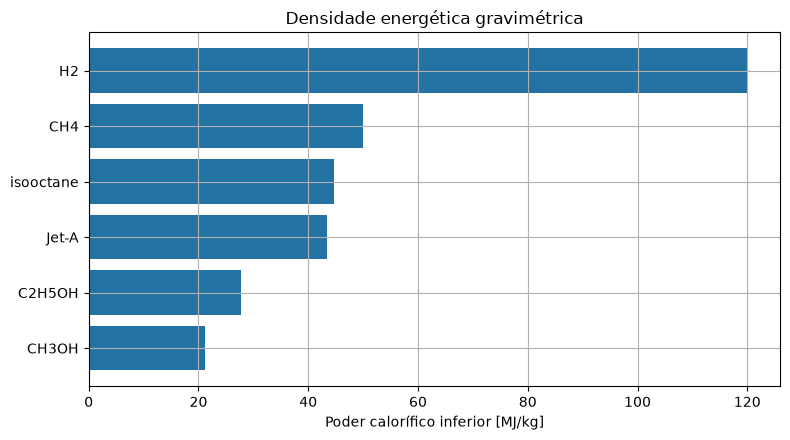

In [5]:
order = fuel_df.sort_values("PCI [MJ/kg]", ascending=True)
fig, ax = plt.subplots()
ax.barh(order.index, order["PCI [MJ/kg]"], color="#2471a3")
ax.set_xlabel("Poder calorífico inferior [MJ/kg]")
ax.set_title("Densidade energética gravimétrica")
fig.tight_layout()
plt.show()

## 4. Intensidade de carbono

CO₂ de combustão direta por unidade de energia entregue. O hidrogênio não emite
nada no ponto de uso; o metano é o hidrocarboneto menos intensivo em carbono
(alta razão H:C).

> **Ressalva sobre o ciclo de vida.** Estas são emissões de *combustão direta*.
> Combustíveis biogênicos (bioetanol, biometano, SAF de biomassa) reciclam o CO₂
> atmosférico, de modo que seu carbono *líquido* no ciclo de vida pode ser muito
> inferior ao mostrado aqui — um tema central do trabalho do GESESC em energias
> renováveis.

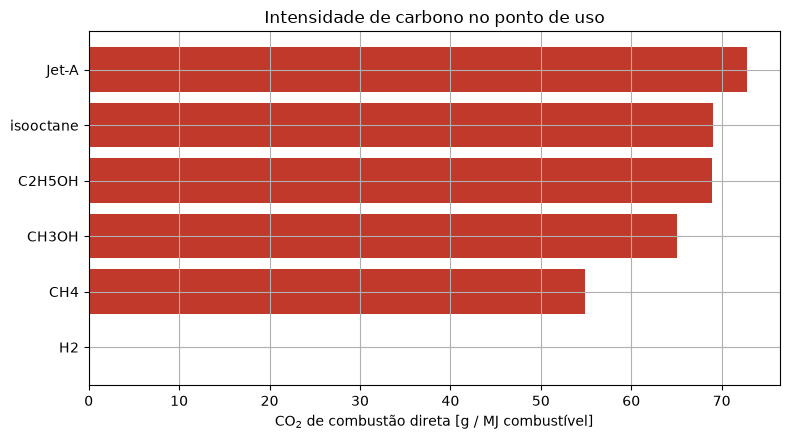

In [6]:
order = fuel_df.sort_values("CO2 [g/MJ]", ascending=True)
colors = ["#27ae60" if v == 0 else "#c0392b" for v in order["CO2 [g/MJ]"]]
fig, ax = plt.subplots()
ax.barh(order.index, order["CO2 [g/MJ]"], color=colors)
ax.set_xlabel("CO$_2$ de combustão direta [g / MJ combustível]")
ax.set_title("Intensidade de carbono no ponto de uso")
fig.tight_layout()
plt.show()

## 5. Razão ar-combustível estequiométrica

A razão A/C dimensiona o sistema de admissão de ar de um motor ou combustor.
Hidrogênio e hidrocarbonetos puros precisam de muito ar por quilograma de
combustível; combustíveis oxigenados precisam de menos porque carregam seu
próprio oxigênio — relevante para a velocidade de chama e formação de NOₓ.

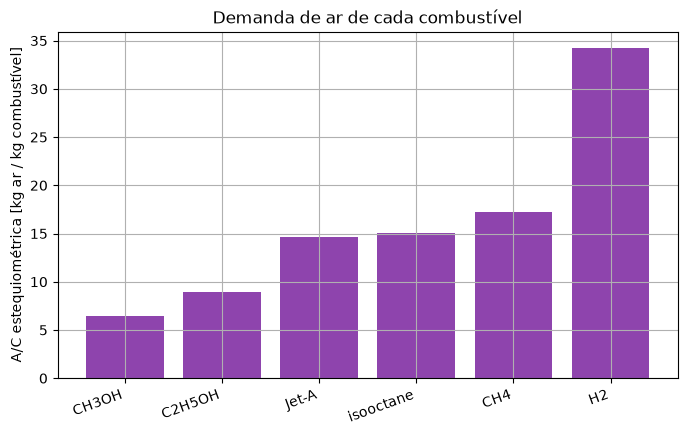

In [7]:
order = fuel_df.sort_values("A/C estequiom. [-]", ascending=True)
fig, ax = plt.subplots()
ax.bar(order.index, order["A/C estequiom. [-]"], color="#8e44ad")
ax.set_ylabel("A/C estequiométrica [kg ar / kg combustível]")
ax.set_title("Demanda de ar de cada combustível")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()

## 6. Poder calorífico vs. temperatura

Para etanol e isooctano, traçamos como o PCI varia com a temperatura (lei de
Kirchhoff, notebook 05). A variação é pequena — alguns por cento —, confirmando
que os poderes caloríficos à temperatura ambiente são utilizáveis em toda a
faixa de temperaturas relevante para combustores.

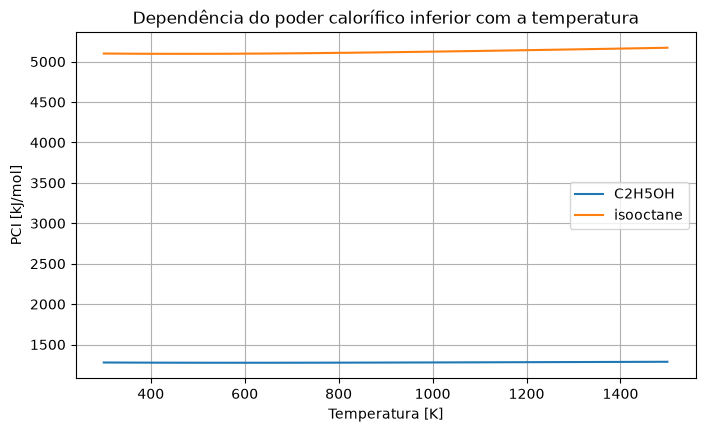

In [8]:
def lhv_at_T(calc, f, T):
    x, y, z = f["x"], f["y"], f["z"]
    nO2 = x + y / 4 - z / 2
    def H(name, nu):
        return nu * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
    dh = (H("CO2", x) + H("H2O", y / 2)) - (H(f["species"], 1) + H("O2", nO2))
    return -dh / 1000.0

Tgrid = np.linspace(300, 1500, 40)
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label in ["C2H5OH", "isooctane"]:
        f = FUELS[label]
        lhv = [lhv_at_T(calc, f, T) for T in Tgrid]
        ax.plot(Tgrid, lhv, label=label)
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("PCI [kJ/mol]")
ax.set_title("Dependência do poder calorífico inferior com a temperatura")
ax.legend()
plt.show()

## Conclusão

- **Bioetanol / metanol**: renováveis e de queima limpa, mas com densidade
  energética ~35–50 % inferior à gasolina — aceitável para transporte
  terrestre, penalizante para aviação.
- **Isooctano / Jet-A**: alta densidade energética gravimétrica e volumétrica —
  daí o impulso por SAF *drop-in* que iguale as propriedades do querosene
  enquanto reduz o carbono no ciclo de vida.
- **Hidrogênio**: energia por quilograma incomparável e zero CO₂ no ponto de
  uso, mas suas características de armazenamento e demanda de ar diferem
  drasticamente dos combustíveis líquidos.

O `pyglenn` torna essa triagem de compromissos em poucas linhas de código —
exatamente o acesso rápido e programático a dados termoquímicos que as notas de
design defendem.

**A seguir:** o notebook 08 aborda equilíbrio químico e energia de Gibbs.